1. Baseline Model - Linear Regression
2. CatBoost
3. Random Forest
4. XGBoost
5. 

### Setup

In [8]:
#Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier, Pool
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss, roc_auc_score

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [9]:
csv_path = Path.cwd().parent / "data" / "all_fights.csv"
data_frame = pd.read_csv(csv_path)

data_frame = pd.read_csv(csv_path)
data_frame = data_frame[~data_frame["blue_stance"].isin(["Switch ", "Open Stance", "Unknown"])]
data_frame = data_frame[~data_frame["red_stance"].isin(["Switch ", "Open Stance", "Unknown"])]

# Drop Catch Weight from weight_class (72 entries)
data_frame = data_frame[~data_frame["weight_class"].isin(["Catch Weight"])]

# Drop reach diff over 40 (1 entry)
data_frame = data_frame[(data_frame["reach_diff"] > -40) & (data_frame["reach_diff"] < 40)]

# Drop round_diff outlier (1 entry)
data_frame = data_frame[(data_frame["rounds_diff"] > -100) & (data_frame["rounds_diff"] < 100)]

# Convert red_winner from string to bool
data_frame["red_winner"] = (data_frame["red_winner"].astype(str).str.lower() == "t").astype(int)
# Convert title bout from string to bool'
data_frame["title_bout"] = (data_frame["title_bout"].astype(str).str.lower() == "t").astype(int)
# ============

# Get all diff features
diff_features = data_frame.filter(regex=r'_diff')
diff_features_no_odds = [f for f in diff_features if f != 'odds_diff']

extra_features = [
    "gender", "weight_class", "red_stance", "blue_stance", "red_age", 
    "blue_age", "b_match_wc_rank", "r_match_wc_rank"
]

#Target
y = data_frame['red_winner']

# Temporal Split

DATE = "2023-06-01"
train_mask = data_frame['fight_date'] <= DATE
test_mask = data_frame['fight_date'] > DATE

y_train = y[train_mask]
y_test = y[test_mask]

# Build feature dataframe with all extras + all diffs (including odds)
all_features_df = pd.concat([data_frame[extra_features], data_frame.filter(regex='_diff')], axis=1)

# Replace instances of rank 20 (unranked) to 16 so ranking distribution is uniform 
worst_rank = max(all_features_df[["b_match_wc_rank", "r_match_wc_rank"]].max().max(), 16) + 1
all_features_df["b_match_wc_rank"] = all_features_df["b_match_wc_rank"].fillna(worst_rank)
all_features_df["r_match_wc_rank"] = all_features_df["r_match_wc_rank"].fillna(worst_rank)

# Age gap is more/less impactful depending on where it sits. A 25 v 28 age gap is less significant 
# than it being 32 v 35 and raw age_diff doesn't see that.
all_features_df["avg_age"] = (all_features_df.red_age + all_features_df.blue_age) / 2
all_features_df["avg_age_c"] = all_features_df["avg_age"] - all_features_df["avg_age"].mean()  # center it

# Create a new column that captures the interaction: how much age_diff's
# effect should be amplified or dampened based on how old the pair is on average
all_features_df["age_diff_x_avg"] = all_features_df["age_diff"] * all_features_df["avg_age_c"]

# Drop raw ages since we already have the affect
all_features_df = all_features_df.drop(columns=["red_age", "blue_age"])

# Split into with/without odds
cols_with_odds = [c for c in all_features_df.columns]
cols_no_odds = [c for c in cols_with_odds if c != 'odds_diff']

# Train/test with odds
X_train_odds = all_features_df.loc[train_mask, cols_with_odds]
X_test_odds = all_features_df.loc[test_mask, cols_with_odds]

#Train/test without odds
X_train_no_odds = all_features_df.loc[train_mask, cols_no_odds]
X_test_no_odds = all_features_df.loc[test_mask, cols_no_odds]



## Testing models
### Baseline Model - Logistic Regression

In [10]:
# Logistic Regression
# Odds included
X_test_dummy_odds = pd.get_dummies(X_test_odds, columns=['gender', 'weight_class', 'red_stance', 'blue_stance'])
X_train_dummy_odds = pd.get_dummies(X_train_odds, columns=['gender', 'weight_class', 'red_stance', 'blue_stance'])
lr = LogisticRegression(max_iter=10000)
lr.fit(X_train_dummy_odds, y_train)
preds_odds = lr.predict(X_test_dummy_odds)
print('=== With Odds Diff ===')
print(accuracy_score(y_test, preds_odds))
print(classification_report(y_test, preds_odds))
# Odds not included
X_test_dummy_no_odds = pd.get_dummies(X_test_no_odds, columns=['gender', 'weight_class', 'red_stance', 'blue_stance'])
X_train_dummy_no_odds = pd.get_dummies(X_train_no_odds, columns=['gender', 'weight_class', 'red_stance', 'blue_stance'])
lr = LogisticRegression(max_iter=10000)
lr.fit(X_train_dummy_no_odds, y_train)
preds_no_odds = lr.predict(X_test_dummy_no_odds)
print('=== Without Odds Diff ===')
print(accuracy_score(y_test, preds_no_odds))
print(classification_report(y_test, preds_no_odds))

=== With Odds Diff ===
0.6996699669966997
              precision    recall  f1-score   support

           0       0.69      0.59      0.64       673
           1       0.71      0.79      0.74       842

    accuracy                           0.70      1515
   macro avg       0.70      0.69      0.69      1515
weighted avg       0.70      0.70      0.70      1515

=== Without Odds Diff ===
0.6026402640264027
              precision    recall  f1-score   support

           0       0.59      0.36      0.45       673
           1       0.61      0.80      0.69       842

    accuracy                           0.60      1515
   macro avg       0.60      0.58      0.57      1515
weighted avg       0.60      0.60      0.58      1515



### Catboost - odds_diff included

In [11]:
# your categorical columns (everything that's object/category dtype)
cat_features = ["gender", "weight_class", "red_stance", "blue_stance"]

X_train_cat = X_train_odds.copy()
X_test_cat = X_test_odds.copy()

# CatBoost needs cats as string, and no NaNs in cat columns (fill or drop first)
for col in cat_features:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_test_cat[col] = X_test_cat[col].astype(str)

train_pool = Pool(X_train_cat, y_train, cat_features=cat_features)
test_pool = Pool(X_test_cat, y_test, cat_features=cat_features)

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric="Accuracy",
    random_seed=26,
    verbose=100  # prints progress every 100 iterations
)

model.fit(train_pool, eval_set=test_pool, early_stopping_rounds=50)

preds = model.predict(X_test_cat)
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

# feature importance
importances = model.get_feature_importance(train_pool, prettified=True)
print(importances)

0:	learn: 0.6528415	test: 0.7042904	best: 0.7042904 (0)	total: 4.84ms	remaining: 2.42s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.704950495
bestIteration = 7

Shrink model to first 8 iterations.
0.7049504950495049
              precision    recall  f1-score   support

           0       0.69      0.62      0.65       673
           1       0.72      0.78      0.75       842

    accuracy                           0.70      1515
   macro avg       0.70      0.70      0.70      1515
weighted avg       0.70      0.70      0.70      1515

                 Feature Id  Importances
0                 odds_diff    88.487540
1                   td_diff     2.611120
2              sig_str_diff     1.900394
3                reach_diff     1.481786
4                  age_diff     1.119471
5                   ko_diff     1.014479
6           win_streak_diff     0.842662
7           b_match_wc_rank     0.812696
8              sub_att_diff     0.544884
9           r_match_wc_r

### Catboost - odds_diff not included

In [28]:
# your categorical columns (everything that's object/category dtype)
cat_features = ["gender", "weight_class", "red_stance", "blue_stance"]

X_train_cat_no_odds = X_train_no_odds.copy()
X_test_cat_no_odds = X_test_no_odds.copy()

# CatBoost needs cats as string, and no NaNs in cat columns (fill or drop first)
for col in cat_features:
    X_train_cat_no_odds[col] = X_train_cat_no_odds[col].astype(str)
    X_test_cat_no_odds[col] = X_test_cat_no_odds[col].astype(str)

train_pool = Pool(X_train_cat_no_odds, y_train, cat_features=cat_features)
test_pool = Pool(X_test_cat_no_odds, y_test, cat_features=cat_features)

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric="Accuracy",
    random_seed=26,
    verbose=100  # prints progress every 100 iterations
)

model.fit(train_pool, eval_set=test_pool, early_stopping_rounds=50)

preds_no_odds = model.predict(X_test_cat_no_odds)
print(accuracy_score(y_test, preds_no_odds))
print(classification_report(y_test, preds_no_odds))
# feature importance
importances = model.get_feature_importance(train_pool, prettified=True)
print(importances)

0:	learn: 0.5887752	test: 0.5524752	best: 0.5524752 (0)	total: 3.47ms	remaining: 1.73s
100:	learn: 0.6561948	test: 0.6033003	best: 0.6085809 (50)	total: 320ms	remaining: 1.26s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6085808581
bestIteration = 50

Shrink model to first 51 iterations.
0.6085808580858085
              precision    recall  f1-score   support

           0       0.64      0.27      0.38       673
           1       0.60      0.88      0.71       842

    accuracy                           0.61      1515
   macro avg       0.62      0.57      0.55      1515
weighted avg       0.62      0.61      0.56      1515

                 Feature Id  Importances
0                  age_diff    26.591779
1                   td_diff    10.851530
2              sig_str_diff     9.258144
3               losses_diff     6.110633
4           win_streak_diff     6.007676
5                red_stance     3.814879
6                reach_diff     3.777530
7             

### Random Forest - odds_diff included

In [13]:
# Random Forest
X_train_forest = X_train_odds.copy()
X_test_forest = X_test_odds.copy()

X_train_dummy_odds = pd.get_dummies(X_train_forest, columns=['gender', 'weight_class', 'red_stance', 'blue_stance'])
X_test_dummy_odds = pd.get_dummies(X_test_forest, columns=['gender', 'weight_class', 'red_stance', 'blue_stance'])

param_grid = {
    'n_estimators' : [100, 200, 500],
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 5, 10, 20]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=26),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1
)
grid_search.fit(X_train_dummy_odds, y_train)

print('=== Best params ===')
print(grid_search.best_params_)
print('=== Best score ===')
print(grid_search.best_score_)

best_rf_odds = grid_search.best_estimator_
preds = best_rf_odds.predict(X_test_dummy_odds)
print('=== Scores ===')
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

print('=== With Odds ===')
importances = pd.Series(best_rf_odds.feature_importances_, index=X_train_dummy_odds.columns)
print(importances.sort_values(ascending=False).head(10))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
=== Best params ===
{'max_depth': None, 'min_samples_leaf': 20, 'n_estimators': 500}
=== Best score ===
0.6565451089722935
=== Scores ===
0.6877887788778878
              precision    recall  f1-score   support

           0       0.69      0.54      0.61       673
           1       0.69      0.80      0.74       842

    accuracy                           0.69      1515
   macro avg       0.69      0.67      0.67      1515
weighted avg       0.69      0.69      0.68      1515

=== With Odds ===
odds_diff         0.377560
age_diff          0.077100
sig_str_diff      0.062300
td_diff           0.061783
age_diff_x_avg    0.042435
sub_att_diff      0.038430
rounds_diff       0.034925
losses_diff       0.032347
reach_diff        0.028847
avg_age           0.026479
dtype: float64


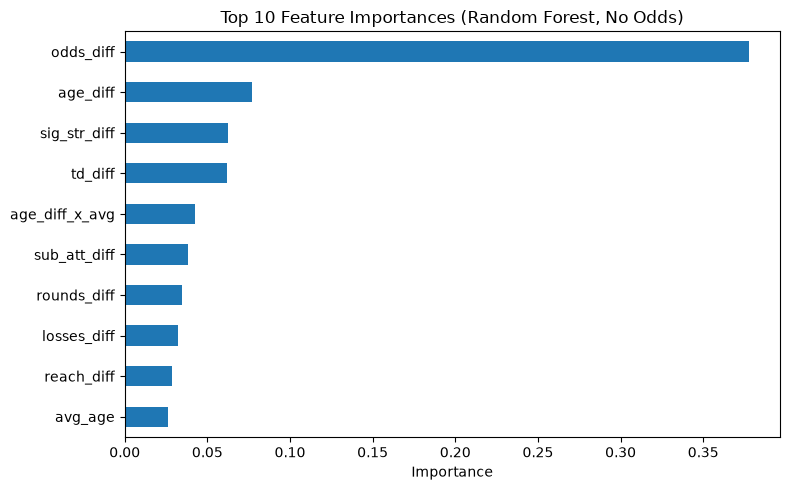

In [ ]:
importances = pd.Series(best_rf_odds.feature_importances_, index=X_train_dummy_odds.columns)
top10 = importances.sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(8, 5))
top10.plot.barh(ax=ax)
ax.set_xlabel('Importance')
ax.set_title('Top 10 Feature Importances (Random Forest, Odds)')
plt.tight_layout()
plt.savefig('../media/feature_importance_rf_odds.png', dpi=150)
plt.show()

### Random Forest - odds_diff not included

In [14]:
X_train_forest_no_odds = X_train_no_odds.copy()
X_test_forest_no_odds = X_test_no_odds.copy()

X_train_dummy_no_odds = pd.get_dummies(X_train_forest_no_odds, columns=['gender', 'weight_class', 'red_stance', 'blue_stance'])
X_test_dummy_no_odds = pd.get_dummies(X_test_forest_no_odds, columns=['gender', 'weight_class', 'red_stance', 'blue_stance'])

param_grid = {
    'n_estimators' : [100, 200, 500],
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 5, 10, 20]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=26),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1
)
grid_search.fit(X_train_dummy_no_odds, y_train)

print('=== Best params ===')
print(grid_search.best_params_)
print('=== Best score ===')
print(grid_search.best_score_)

best_rf_no_odds = grid_search.best_estimator_
preds = best_rf_no_odds.predict(X_test_dummy_no_odds)
print('=== Scores ===')
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

print('=== Importances ===')
importances = pd.Series(best_rf_no_odds.feature_importances_, index=X_train_dummy_no_odds.columns)
print(importances.sort_values(ascending=False).head(10))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
=== Best params ===
{'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}
=== Best score ===
0.6094218498749243
=== Scores ===
0.6072607260726073
              precision    recall  f1-score   support

           0       0.62      0.30      0.40       673
           1       0.60      0.85      0.71       842

    accuracy                           0.61      1515
   macro avg       0.61      0.58      0.56      1515
weighted avg       0.61      0.61      0.57      1515

=== Importances ===
age_diff          0.119036
td_diff           0.094281
sig_str_diff      0.085617
age_diff_x_avg    0.060454
sub_att_diff      0.056079
rounds_diff       0.052886
losses_diff       0.051479
reach_diff        0.040512
avg_age_c         0.039430
avg_age           0.037542
dtype: float64


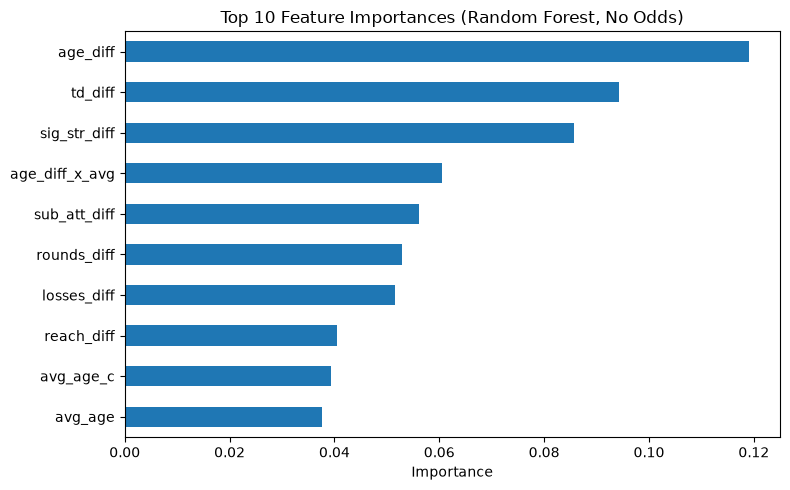

In [32]:
importances = pd.Series(best_rf_no_odds.feature_importances_, index=X_train_dummy_no_odds.columns)
top10 = importances.sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(8, 5))
top10.plot.barh(ax=ax)
ax.set_xlabel('Importance')
ax.set_title('Top 10 Feature Importances (Random Forest, No Odds)')
plt.tight_layout()
plt.savefig('../media/feature_importance_rf_no_odds.png', dpi=150)
plt.show()

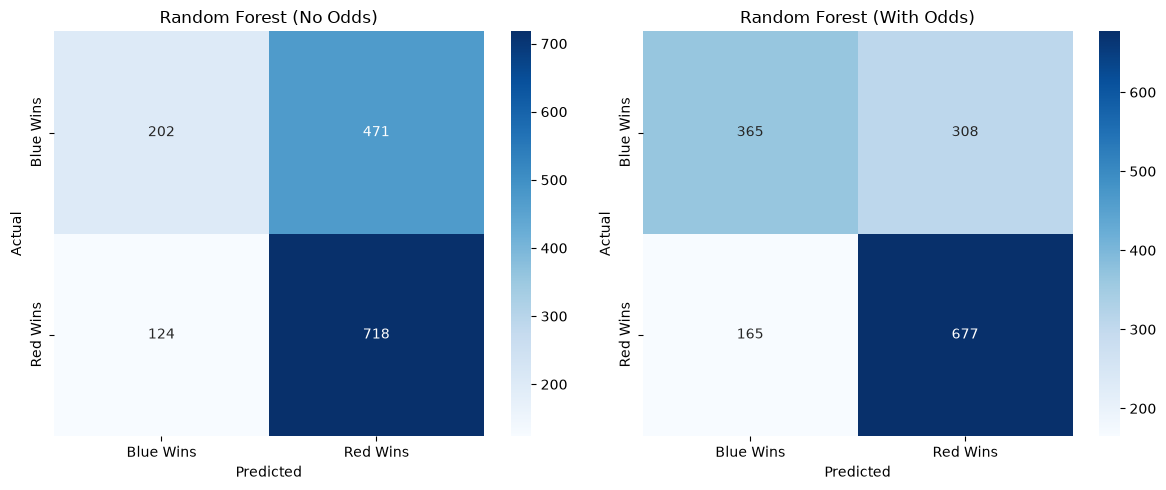

In [34]:
# Comparison between odds and no odds forest
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in [
    (axes[0], best_rf_no_odds.predict(X_test_dummy_no_odds), 'Random Forest (No Odds)'),
    (axes[1], best_rf_odds.predict(X_test_dummy_odds), 'Random Forest (With Odds)')
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Blue Wins', 'Red Wins'],
                yticklabels=['Blue Wins', 'Red Wins'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('../media/random_forest_comparison.png', dpi=150)
plt.show()


### XGBoost - odds_diff included

In [49]:
categorical_features = ["red_stance", "blue_stance", "weight_class", "gender"]
numeric_features = [
    "odds_diff", "age_diff", "td_diff", "sig_str_diff", "reach_diff", "losses_diff",
    "sub_att_diff", "rank_diff",
    "win_streak_diff", "longest_win_streak_diff", "lose_streak_diff",
    "title_bout_diff", "wins_diff", "rounds_diff", "height_diff",
    "ko_diff", "submission_diff", "b_match_wc_rank", "r_match_wc_rank", 
    "avg_age", "avg_age_c", "age_diff_x_avg"
]

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

pipeline_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("clf", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

param_grid = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [3, 6],
    "clf__learning_rate": [0.01, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0]
}

grid_search_odds = GridSearchCV(
    pipeline_xgb,
    param_grid,
    cv=5,
    scoring="roc_auc",   # accuracy alone is weak if red_winner is imbalanced — see note below
    n_jobs=-1,
    return_train_score=True
)

grid_search_odds.fit(X_train_odds, y_train)

print("Best parameters:")
print(grid_search_odds.best_params_)
print()
print("Best cross-validation ROC-AUC:")
print(grid_search_odds.best_score_)

best_index = grid_search_odds.best_index_
print("Training score:", grid_search_odds.cv_results_["mean_train_score"][best_index])
print("Validation score:", grid_search_odds.cv_results_["mean_test_score"][best_index])


best_xgb_odds = grid_search_odds.best_estimator_
preds = best_xgb_odds.predict(X_test_odds)
print('=== Test Set ===')
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Best parameters:
{'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.8}

Best cross-validation ROC-AUC:
0.7056627887107684
Training score: 0.7271824618382718
Validation score: 0.7056627887107684
=== Test Set ===
0.6792079207920793
              precision    recall  f1-score   support

           0       0.72      0.46      0.56       673
           1       0.66      0.86      0.75       842

    accuracy                           0.68      1515
   macro avg       0.69      0.66      0.65      1515
weighted avg       0.69      0.68      0.66      1515



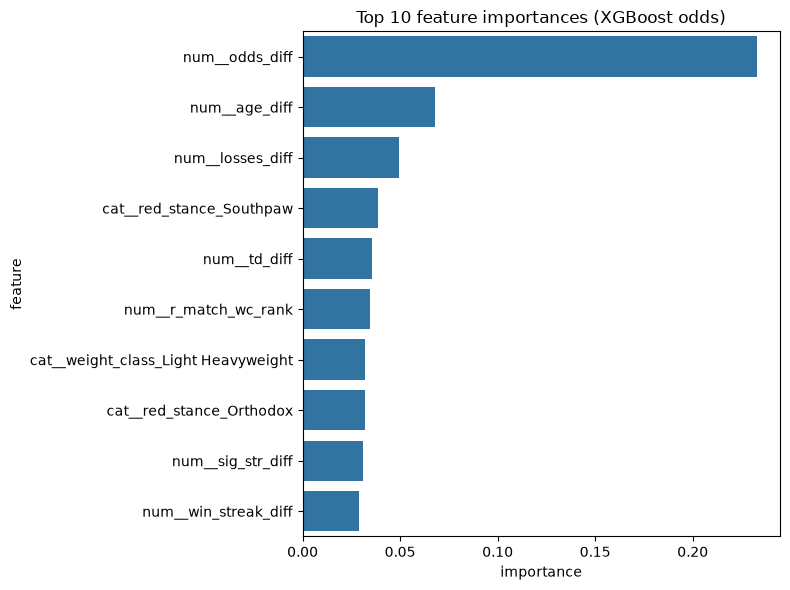

In [60]:
best_model = grid_search_odds.best_estimator_
xgb_clf = best_model.named_steps["clf"]

# Get feature names after one-hot encoding
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

importances = xgb_clf.feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(10), x="importance", y="feature")
plt.title("Top 10 feature importances (XGBoost odds)")
plt.tight_layout()
plt.savefig('../media/xbg_odds_feature_importance.png', dpi=150)
plt.show()

### XGBoost - odds_diff not included

In [51]:
categorical_features = ["red_stance", "blue_stance", "weight_class", "gender"]
numeric_features = [
    "age_diff", "td_diff", "sig_str_diff", "reach_diff", "losses_diff",
    "sub_att_diff", "rank_diff",
    "win_streak_diff", "longest_win_streak_diff", "lose_streak_diff",
    "title_bout_diff", "wins_diff", "rounds_diff", "height_diff",
    "ko_diff", "submission_diff", "b_match_wc_rank", "r_match_wc_rank", 
    "avg_age", "avg_age_c", "age_diff_x_avg"
]

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

pipeline_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("clf", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

param_grid = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [3, 6],
    "clf__learning_rate": [0.01, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0]
}

grid_search_no_odds = GridSearchCV(
    pipeline_xgb,
    param_grid,
    cv=5,
    scoring="roc_auc",   # accuracy alone is weak if red_winner is imbalanced — see note below
    n_jobs=-1,
    return_train_score=True
)

grid_search_no_odds.fit(X_train_no_odds, y_train)

print("Best parameters:")
print(grid_search_no_odds.best_params_)
print()
print("Best cross-validation ROC-AUC:")
print(grid_search_no_odds.best_score_)

best_index = grid_search_no_odds.best_index_
print("Training score:", grid_search_no_odds.cv_results_["mean_train_score"][best_index])
print("Validation score:", grid_search_no_odds.cv_results_["mean_test_score"][best_index])

best_xgb_no_odds = grid_search_no_odds.best_estimator_
preds = best_xgb_no_odds.predict(X_test_no_odds)
print('=== Test Set ===')
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Best parameters:
{'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 300, 'clf__subsample': 0.8}

Best cross-validation ROC-AUC:
0.6133171885105659
Training score: 0.6887583264588951
Validation score: 0.6133171885105659
=== Test Set ===
0.6052805280528053
              precision    recall  f1-score   support

           0       0.63      0.27      0.38       673
           1       0.60      0.87      0.71       842

    accuracy                           0.61      1515
   macro avg       0.61      0.57      0.55      1515
weighted avg       0.61      0.61      0.56      1515



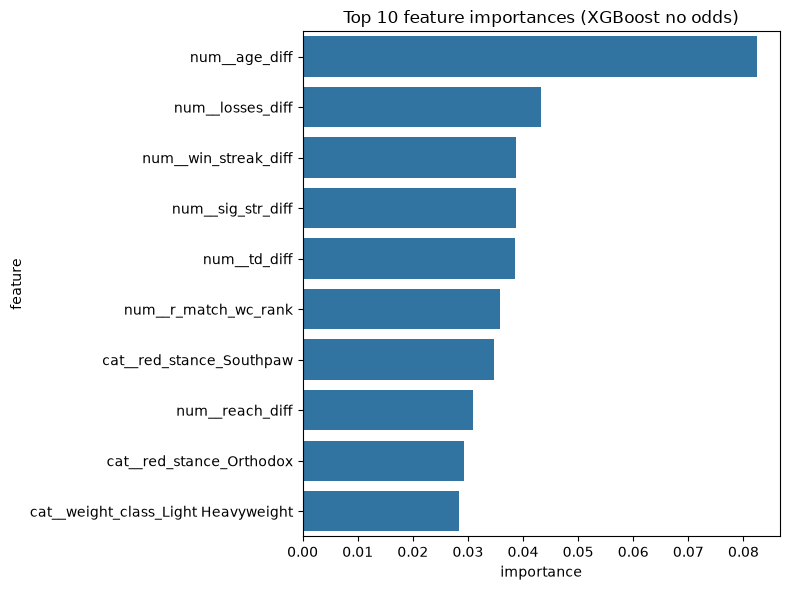

In [59]:
best_model = grid_search_no_odds.best_estimator_
xgb_clf = best_model.named_steps["clf"]

# Get feature names after one-hot encoding
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

importances = xgb_clf.feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(10), x="importance", y="feature")
plt.title("Top 10 feature importances (XGBoost no odds)")
plt.tight_layout()
plt.savefig('../media/xbg_no_odds_feature_importance.png', dpi=150)
plt.show()

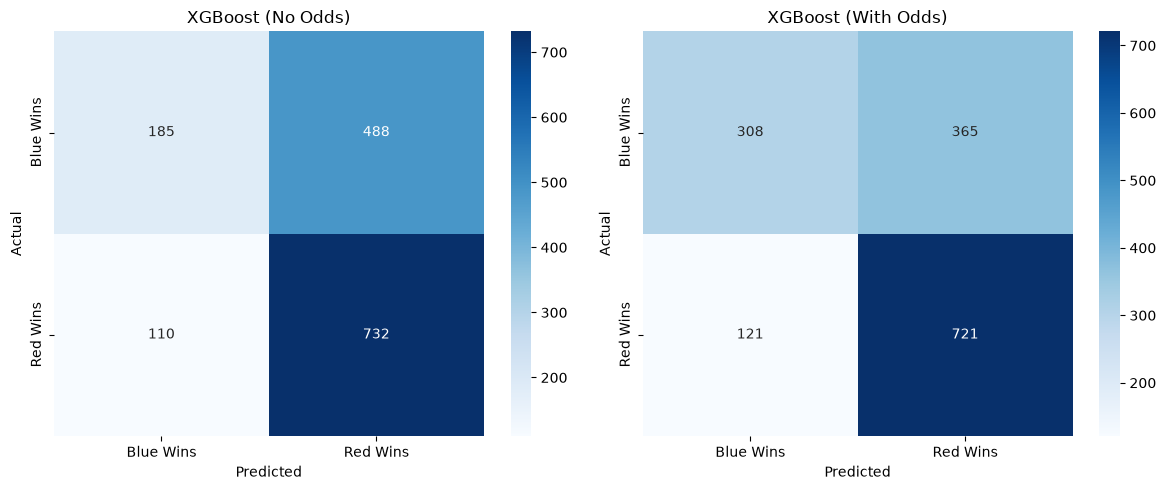

In [55]:
# Comparison between XGB no odds and odds
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in [
    (axes[0], best_xgb_no_odds.predict(X_test_no_odds), 'XGBoost (No Odds)'),
    (axes[1], best_xgb_odds.predict(X_test_odds), 'XGBoost (With Odds)')
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Blue Wins', 'Red Wins'],
                yticklabels=['Blue Wins', 'Red Wins'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('../media/xgb_comparison.png', dpi=150)
plt.show()


### Random Forest 2 - odds_diff included

{'clf__bootstrap': True, 'clf__max_depth': 12, 'clf__min_samples_leaf': 15, 'clf__n_estimators': 400}
0.6999217042729817
Accuracy Score:  0.6904290429042904
Classification Report 

              precision    recall  f1-score   support

           0       0.69      0.54      0.61       673
           1       0.69      0.81      0.74       842

    accuracy                           0.69      1515
   macro avg       0.69      0.68      0.68      1515
weighted avg       0.69      0.69      0.68      1515

                               Feature  Importance
2                            odds_diff   36.885415
3                             age_diff    7.624276
17                             td_diff    6.047171
15                        sig_str_diff    5.971722
21                      age_diff_x_avg    4.157895
16                        sub_att_diff    3.655482
8                          rounds_diff    3.466581
7                          losses_diff    3.289457
4                           reach

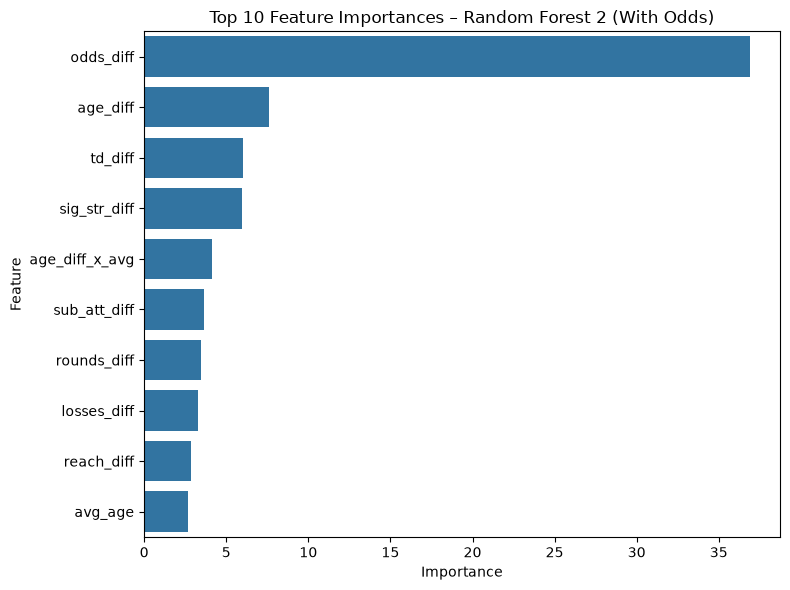

Test AUC score:  0.742
Log-Loss score:  0.6041767353725829
ROC AUC score:  0.7422749909117541


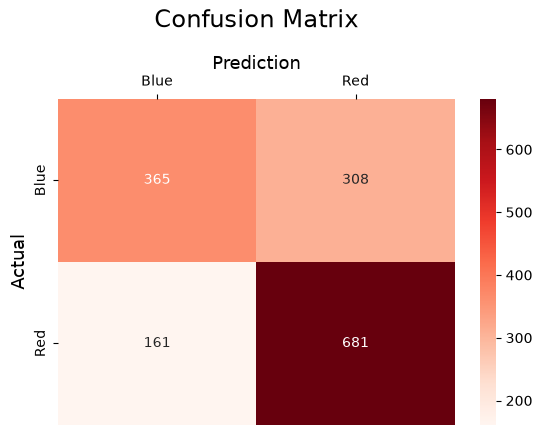

In [56]:
cat_features = ["gender", "weight_class", "red_stance", "blue_stance"]

# Collect every non-categorical feature (continuous) into an array
num_features = [c for c in X_train_odds.columns if c not in cat_features]

pre_tree = ColumnTransformer([
    ("num", "passthrough", num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

params = {
    "clf__n_estimators": [100, 400],
    "clf__max_depth": [4, 12],
    "clf__min_samples_leaf": [15, 45],
    "clf__bootstrap": [True, False],
}


randforrest = Pipeline([
    ("pre", pre_tree),
    ("clf", RandomForestClassifier(n_jobs=-1, random_state=42))
])

grid_search = GridSearchCV(
    estimator=randforrest,
    param_grid=params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train_odds, y_train)

best_model_odds = grid_search.best_estimator_
print(grid_search.best_params_)
print(grid_search.best_score_)

proba = best_model_odds.predict_proba(X_test_odds)[:, 1]
preds = best_model_odds.predict(X_test_odds)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


print("Accuracy Score: ", accuracy_score(y_test, preds))

print("Classification Report \n")
print(classification_report(y_test, preds))

encoded_features = best_model_odds.named_steps["pre"].named_transformers_["cat"] 
encoded_names = list(encoded_features.get_feature_names_out(cat_features))
features_names = num_features + encoded_names

importances = (best_model_odds.named_steps["clf"].feature_importances_) * 100
feature_imp_df = pd.DataFrame({"Feature" : features_names, "Importance" : importances}).sort_values("Importance", ascending=False)

print(feature_imp_df)

plt.figure(figsize=(8, 6))
sns.barplot(data=feature_imp_df.head(10), x="Importance", y="Feature")
plt.title("Top 10 Feature Importances – Random Forest 2 (With Odds)")
plt.tight_layout()
plt.savefig('../media/rf2_odds_feature_importance.png', dpi=150)
plt.show()


test_auc = round(roc_auc_score(y_test, proba), 3)
print("Test AUC score: ", test_auc)
print("Log-Loss score: ", log_loss(y_test, proba))
print("ROC AUC score: ", roc_auc_score((y_test == True), proba))

conf_matrix = confusion_matrix(y_test, preds, labels=[False, True])

sns.heatmap(conf_matrix, 
            annot=True,
            fmt="d", 
            cmap="Reds",
            xticklabels=["Blue","Red"],
            yticklabels=["Blue","Red"])

plt.ylabel("Actual", fontsize=13)
plt.title("Confusion Matrix", fontsize=17, pad=20)
plt.gca().xaxis.set_label_position("top") 
plt.xlabel("Prediction", fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.show()



### Random Forest 2 - odds_diff not included

{'clf__bootstrap': True, 'clf__max_depth': 12, 'clf__min_samples_leaf': 45, 'clf__n_estimators': 400}
0.6152774530074924
Accuracy Score:  0.6092409240924093
Classification Report 

              precision    recall  f1-score   support

           0       0.63      0.29      0.40       673
           1       0.60      0.86      0.71       842

    accuracy                           0.61      1515
   macro avg       0.62      0.58      0.55      1515
weighted avg       0.62      0.61      0.57      1515

                               Feature  Importance
2                             age_diff   20.434358
16                             td_diff   10.789215
14                        sig_str_diff    9.033670
6                          losses_diff    7.250093
20                      age_diff_x_avg    5.820265
15                        sub_att_diff    4.943365
11                     win_streak_diff    4.580765
7                          rounds_diff    4.398650
3                           reach

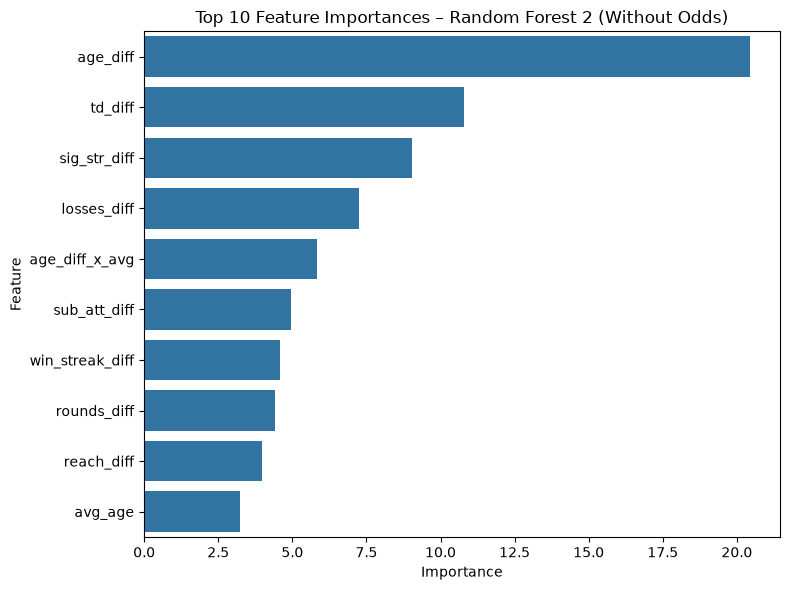

Test AUC score:  0.654
Log-Loss score:  0.6569505168228748
ROC AUC score:  0.6536072395379289


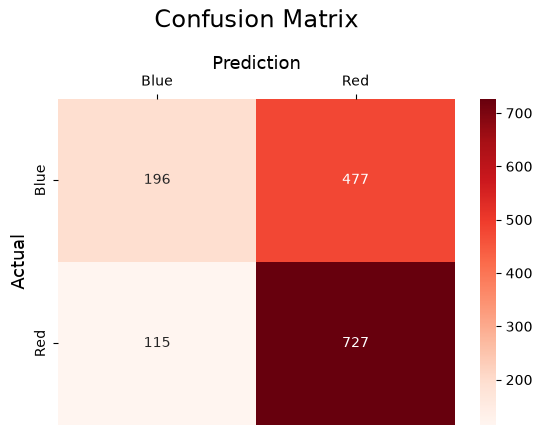

In [57]:
cat_features = ["gender", "weight_class", "red_stance", "blue_stance"]

# Collect every non-categorical feature (continuous) into an array
num_features = [c for c in X_train_no_odds.columns if c not in cat_features]

pre_tree = ColumnTransformer([
    ("num", "passthrough", num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

params = {
    "clf__n_estimators": [100, 400],
    "clf__max_depth": [4, 12],
    "clf__min_samples_leaf": [15, 45],
    "clf__bootstrap": [True, False],
}


randforrest = Pipeline([
    ("pre", pre_tree),
    ("clf", RandomForestClassifier(n_jobs=-1, random_state=42))
])

grid_search = GridSearchCV(
    estimator=randforrest,
    param_grid=params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train_no_odds, y_train)

best_model_no_odds = grid_search.best_estimator_
print(grid_search.best_params_)
print(grid_search.best_score_)

proba = best_model_no_odds.predict_proba(X_test_no_odds)[:, 1]
preds = best_model_no_odds.predict(X_test_no_odds)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


print("Accuracy Score: ", accuracy_score(y_test, preds))

print("Classification Report \n")
print(classification_report(y_test, preds))

encoded_features = best_model_no_odds.named_steps["pre"].named_transformers_["cat"] 
encoded_names = list(encoded_features.get_feature_names_out(cat_features))
features_names = num_features + encoded_names

importances = (best_model_no_odds.named_steps["clf"].feature_importances_) * 100
feature_imp_df = pd.DataFrame({"Feature" : features_names, "Importance" : importances}).sort_values("Importance", ascending=False)

print(feature_imp_df)

plt.figure(figsize=(8, 6))
sns.barplot(data=feature_imp_df.head(10), x="Importance", y="Feature")
plt.title("Top 10 Feature Importances – Random Forest 2 (Without Odds)")
plt.tight_layout()
plt.savefig('../media/rf2_no_odds_feature_importance.png', dpi=150)
plt.show()


test_auc = round(roc_auc_score(y_test, proba), 3)
print("Test AUC score: ", test_auc)
print("Log-Loss score: ", log_loss(y_test, proba))
print("ROC AUC score: ", roc_auc_score((y_test == True), proba))

conf_matrix = confusion_matrix(y_test, preds, labels=[False, True])

sns.heatmap(conf_matrix, 
            annot=True,
            fmt="d", 
            cmap="Reds",
            xticklabels=["Blue","Red"],
            yticklabels=["Blue","Red"])

plt.ylabel("Actual", fontsize=13)
plt.title("Confusion Matrix", fontsize=17, pad=20)
plt.gca().xaxis.set_label_position("top") 
plt.xlabel("Prediction", fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.show()



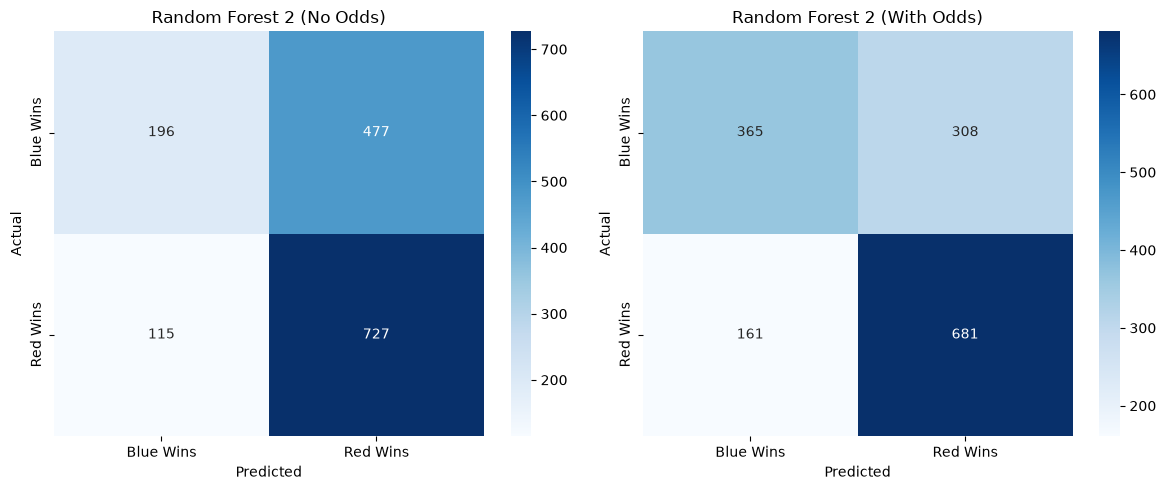

In [58]:
# RF2 Confusion Matrix: Odds vs No Odds
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, X_test, title in [
    (axes[0], best_model_no_odds, X_test_no_odds, 'Random Forest 2 (No Odds)'),
    (axes[1], best_model_odds, X_test_odds, 'Random Forest 2 (With Odds)')
]:
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Blue Wins', 'Red Wins'],
                yticklabels=['Blue Wins', 'Red Wins'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('../media/rf2_comparison.png', dpi=150)
plt.show()


### MORE THINGS

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


x_train = X_train_odds


# --- Feature groups ---
categorical_features = ["red_stance", "blue_stance", "weight_class", "gender" ]
numeric_features = [
    "odds_diff", "age_diff", "td_diff", "sig_str_diff", "reach_diff", "losses_diff",
    "sub_att_diff", "rank_diff", "win_streak_diff", "longest_win_streak_diff",
    "lose_streak_diff", "title_bout_diff", "wins_diff", "rounds_diff",
    "height_diff", "ko_diff", "submission_diff"
]

# --- Preprocessors ---
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

preprocessor_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

# --- Pipelines ---
pipeline_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("clf", XGBClassifier(eval_metric="logloss", random_state=42))
])

pipeline_lr = Pipeline([
    ("preprocess", preprocessor_scaled),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_rf = Pipeline([
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(random_state=42))
])

pipeline_knn = Pipeline([
    ("preprocess", preprocessor_scaled),
    ("clf", KNeighborsClassifier())
])

# --- Param grids ---
param_grid_xgb = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [3, 6],
    "clf__learning_rate": [0.01, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0]
}

param_grid_lr = {
    "clf__C": [0.01, 0.1, 1.0, 10.0],
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["liblinear"]
}

param_grid_rf = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_leaf": [1, 5],
    "clf__max_features": ["sqrt", "log2"]
}

param_grid_knn = {
    "clf__n_neighbors": [5, 11, 21, 31],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2]
}

# --- Grid searches ---
grid_search_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=5,
                                scoring="roc_auc", n_jobs=-1, return_train_score=True)
grid_search_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5,
                               scoring="roc_auc", n_jobs=-1, return_train_score=True)
grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5,
                               scoring="roc_auc", n_jobs=-1, return_train_score=True)
grid_search_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=5,
                                scoring="roc_auc", n_jobs=-1, return_train_score=True)

grid_search_xgb.fit(x_train, y_train)
print("XGBoost done —", grid_search_xgb.best_params_, grid_search_xgb.best_score_)

grid_search_lr.fit(x_train, y_train)
print("Logistic Regression done —", grid_search_lr.best_params_, grid_search_lr.best_score_)

grid_search_rf.fit(x_train, y_train)
print("Random Forest done —", grid_search_rf.best_params_, grid_search_rf.best_score_)

grid_search_knn.fit(x_train, y_train)
print("kNN done —", grid_search_knn.best_params_, grid_search_knn.best_score_)

# --- Summary table ---
results_summary = pd.DataFrame({
    "model": ["XGBoost", "Logistic Regression", "Random Forest", "kNN"],
    "best_cv_roc_auc": [
        grid_search_xgb.best_score_,
        grid_search_lr.best_score_,
        grid_search_rf.best_score_,
        grid_search_knn.best_score_
    ]
}).sort_values("best_cv_roc_auc", ascending=False)

print()
print(results_summary)

XGBoost done — {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.8} 0.7064572157592854


/Users/hreimur/Documents/MachineLearningRepo/env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/hreimur/Documents/MachineLearningRepo/env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warni

Logistic Regression done — {'clf__C': 0.01, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'} 0.7090324601317619
Random Forest done — {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 300} 0.7006661242897901
kNN done — {'clf__n_neighbors': 31, 'clf__p': 2, 'clf__weights': 'uniform'} 0.6502236679467188

                 model  best_cv_roc_auc
1  Logistic Regression         0.709032
0              XGBoost         0.706457
2        Random Forest         0.700666
3                  kNN         0.650224


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

# --- Feature groups ---
categorical_features = ["gender", "weight_class", "red_stance", "blue_stance"]
numeric_features = [
    "odds_diff", "age_diff", "td_diff", "sig_str_diff", "reach_diff", "losses_diff",
    "sub_att_diff", "rank_diff", "win_streak_diff", "longest_win_streak_diff",
    "lose_streak_diff", "title_bout_diff", "wins_diff", "rounds_diff",
    "height_diff", "ko_diff", "submission_diff"
]

# --- Preprocessing: impute only — CatBoost handles cats and scale itself ---
preprocessor = ColumnTransformer([
    ("cat", SimpleImputer(strategy="constant", fill_value="missing"), categorical_features),
    ("num", SimpleImputer(strategy="median"), numeric_features)
], verbose_feature_names_out=False).set_output(transform="pandas")

# force categorical columns back to string after imputation (SimpleImputer can upcast dtypes)
def cast_cats_to_str(df):
    df = df.copy()
    df[categorical_features] = df[categorical_features].astype(str)
    return df

cast_step = FunctionTransformer(cast_cats_to_str)

# --- Pipeline (no cat_features in the constructor — passed via fit() instead) ---
pipeline_cb = Pipeline([
    ("preprocess", preprocessor),
    ("cast", cast_step),
    ("clf", CatBoostClassifier(
        random_seed=26,
        verbose=0
    ))
])

# --- Param grid ---
""" param_grid_cb = {
    "clf__iterations": [300, 500],
    "clf__learning_rate": [0.03, 0.05, 0.1],
    "clf__depth": [4, 6, 8],
    "clf__l2_leaf_reg": [1, 3, 5]
} """

param_grid_cb = {
    "clf__iterations": [300, 500],
    "clf__learning_rate": [0.03, 0.05],
    "clf__depth": [4, 6],
    "clf__l2_leaf_reg": [1, 3]
}
# Hyper parameters for CatBoostClassifier


# --- Grid search ---
grid_search_cb = GridSearchCV(
    pipeline_cb, param_grid_cb,
    cv=5, scoring="roc_auc", n_jobs=-1, return_train_score=True
)


# cat_features passed here via clf__ prefix, forwarded to CatBoostClassifier.fit() on every fold
grid_search_cb.fit(x_train, y_train, clf__cat_features=categorical_features)

print("Best parameters:")
print(grid_search_cb.best_params_)
print()
print("Best cross-validation ROC-AUC:")
print(grid_search_cb.best_score_)

best_index = grid_search_cb.best_index_
print("Training score:", grid_search_cb.cv_results_["mean_train_score"][best_index])
print("Validation score:", grid_search_cb.cv_results_["mean_test_score"][best_index])

Best parameters:
{'clf__depth': 4, 'clf__iterations': 300, 'clf__l2_leaf_reg': 3, 'clf__learning_rate': 0.03}

Best cross-validation ROC-AUC:
0.7077546740994396
Training score: 0.7421016870461266
Validation score: 0.7077546740994396


### Plot stuff

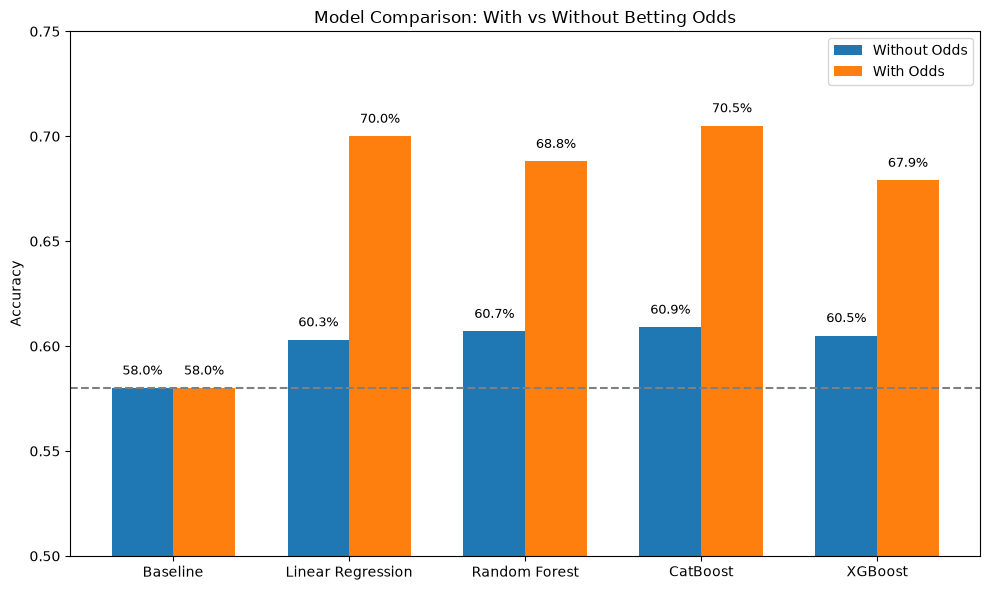

In [21]:
# Plot 1 Model comparison bar chart
results = pd.DataFrame({
    'Model': ['Baseline', 'Linear Regression', 'Random Forest', 'CatBoost', 'XGBoost'],
    'Without Odds': [0.58, 0.603, 0.607, 0.609, 0.605],
    'With Odds':    [0.58, 0.700, 0.688, 0.705, 0.679]
})

x = np.arange(len(results))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, results['Without Odds'], width, label='Without Odds')
bars2 = ax.bar(x + width/2, results['With Odds'], width, label='With Odds')

ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: With vs Without Betting Odds')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.legend()
ax.set_ylim(0.50, 0.75)
ax.axhline(y=0.58, color='gray', linestyle='--', label='Baseline')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../media/model_comparison.png', dpi=150)
plt.show()
